In [106]:
import matplotlib.pyplot as plt
import csv

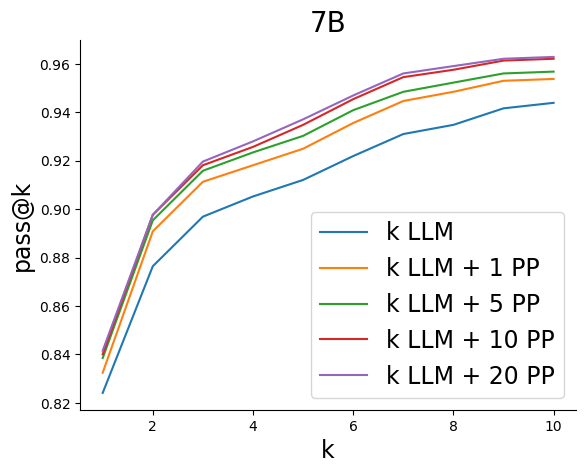

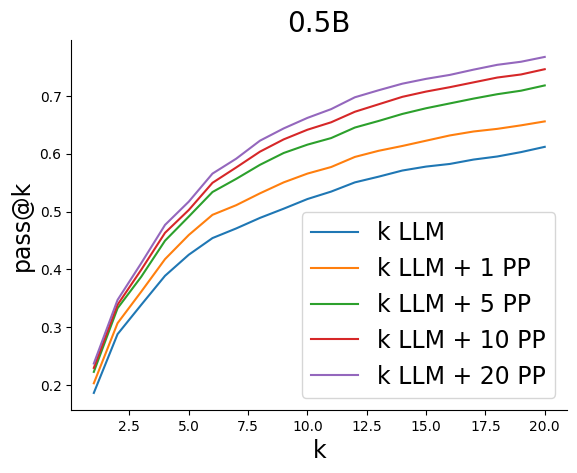

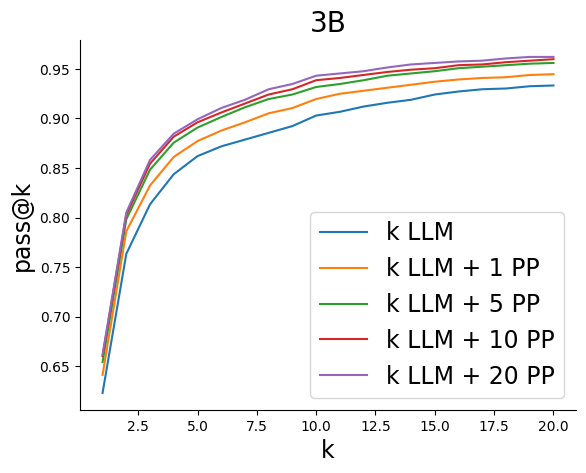

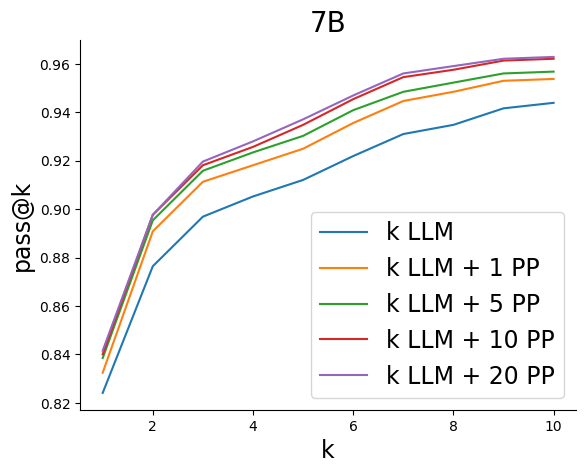

In [107]:
def plotkvsaccuracy(model_size: int, exp_name:str):
    file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7/accuracy.csv"
    data_list = []

    with open(file_path, mode='r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for row in csv_reader:
            data_list.append(row)

    data_list = data_list[1 if exp_name == "gsm8k" else 2:]

    def plot_pp_data(ax, num_samples):
        pp_data_list = list(filter(lambda x: int(x[1]) == num_samples + (0 if exp_name == "gsm8k" else 1), data_list))

        x = [int(i[0]) for i in pp_data_list]
        y = [float(i[2]) for i in pp_data_list]
        ax.plot(x, y)

    fig, ax = plt.subplots()
    plot_pp_data(ax, 0)
    plot_pp_data(ax, 1)
    plot_pp_data(ax, 5)
    plot_pp_data(ax, 10)
    plot_pp_data(ax, 20)
    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("pass@k", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 20 PP"], fontsize=17)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f"{model_size}B", fontsize=20)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/pass@k_{model_size}B.pdf", dpi=300)
    return fig

plotkvsaccuracy(0.5, "gsm8k")
plotkvsaccuracy(3, "gsm8k")
plotkvsaccuracy(7, "gsm8k")


1.0 1.0
0.8302261265710106 1.2993949964863616
0.8310453861802305 1.3164851762233467
0.8344719479927676 1.3272978230971026
0.8371888511891573 1.3405167824479864
0.8426526443396852 1.3671796044515532
1.0 1.0
0.9558352048984934 1.3619171883763936
0.9604929028610215 1.383857757900843
0.9678316269968155 1.3922486894802242
0.9709487600315097 1.4167623673332652
0.9729048225902895 1.436494690419516
1.0 1.0
0.9885408053974462 1.168990110952058
1.000318266959956 1.1726893925660944
1.0152248191816362 1.177312582752845
1.0260287929066072 1.1816523599159683
1.0286147658021114 1.1860129831394985


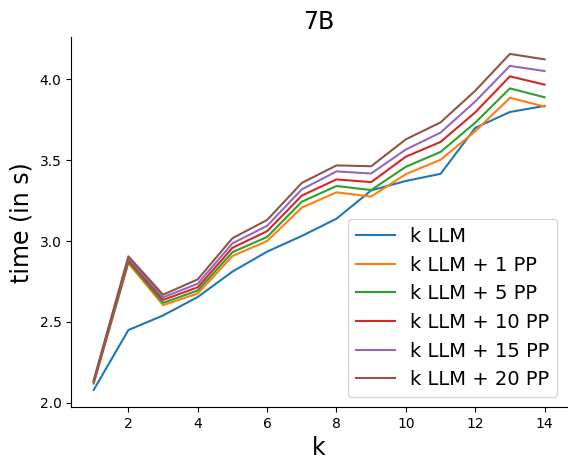

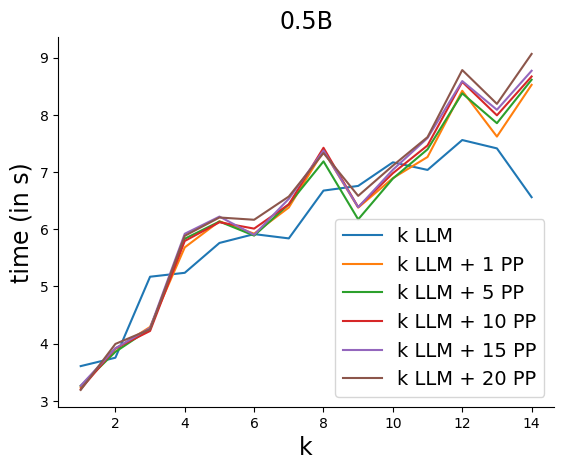

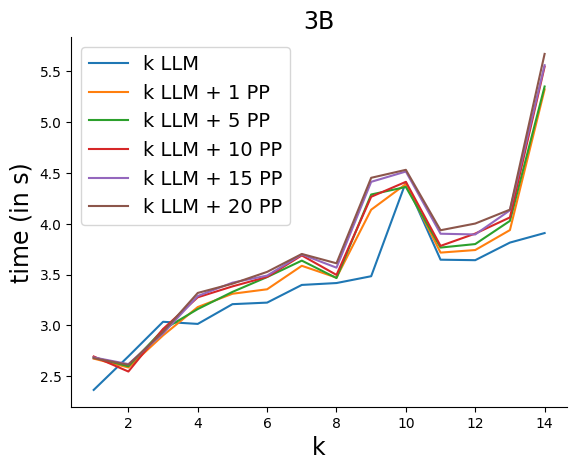

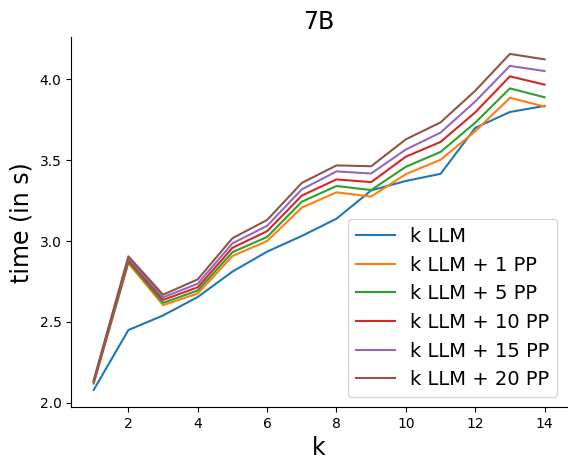

In [108]:
def plotkvstime(model_size: int, exp_name: str):
    folder_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7"
    data_list = []

    def plot_pp_data(ax, pp_samples):
        x = []
        y = []
        speedup = []
        for i in range(1, 15):
            pp_samples_file = 1 if pp_samples == 0 else pp_samples
            fast_suffix = "_fast" if exp_name == "gsm8k" else ""
            file_path = f"{folder_path}/time_{i}_{pp_samples_file}{fast_suffix}.txt"
            # print(file_path)
            # print(fast_suffix)
            with open(file_path, mode='r') as f:
                lines = f.readlines()
                x.append(i)
                line_idx = 3 if pp_samples == 0 else 7
                time = float(lines[line_idx].split(":")[1])
                baseline_time = float(lines[3].split(":")[1])
                speedup.append(time / baseline_time)
                y.append(time)
        print(min(speedup), max(speedup))
        ax.plot(x, y)

    fig, ax = plt.subplots()
    plot_pp_data(ax, 0)
    plot_pp_data(ax, 1)
    plot_pp_data(ax, 5)
    plot_pp_data(ax, 10)
    plot_pp_data(ax, 15)
    plot_pp_data(ax, 20)
    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("time (in s)", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 15 PP", "k LLM + 20 PP"], fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f"{model_size}B", fontsize=17)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/time_{model_size}B.pdf", dpi=300)
    return fig

plotkvstime(0.5, "gsm8k")
plotkvstime(3, "gsm8k")
plotkvstime(7, "gsm8k")

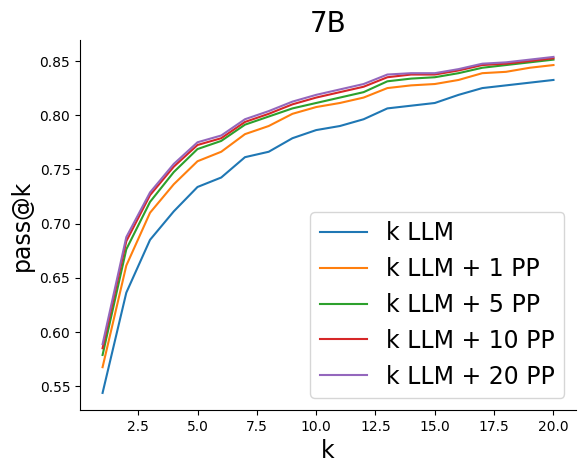

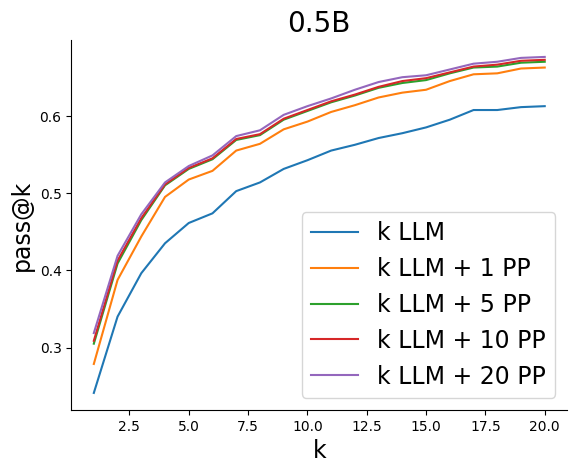

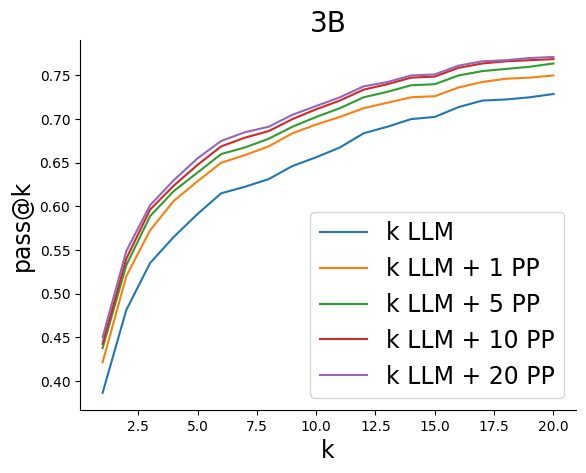

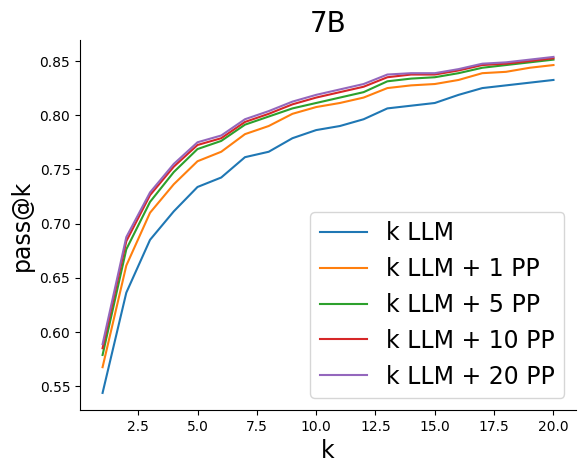

In [109]:
plotkvsaccuracy(0.5, "cruxeval_new")
plotkvsaccuracy(3, "cruxeval_new")
plotkvsaccuracy(7, "cruxeval_new")

1.0 1.0
0.9855767160313929 1.34735349800651
1.0848052998292816 1.5176525846762787
1.1124305280601987 1.7759316843490593
1.1713236504507885 2.06156595628946
1.223162967134127 2.690353522322346
1.0 1.0
0.8707495877235429 1.409781974943334
0.9628451584444385 1.7148674368846113
1.0014421337797192 2.279108226278677
1.035591442732675 3.510176654108093
1.0713105650305303 3.644330240463442
1.0 1.0
0.9219941802144708 1.2683367470545057
1.0475004872385392 1.4976326347535258
1.0922570819611355 1.904951343347476
1.1274667069327333 2.1332059946798556
1.1611692630895993 2.683735243274425


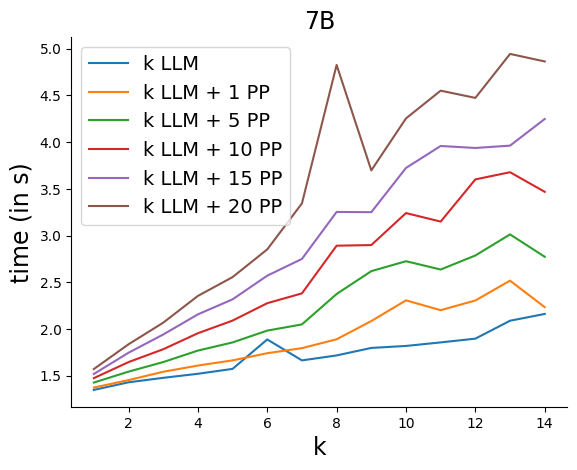

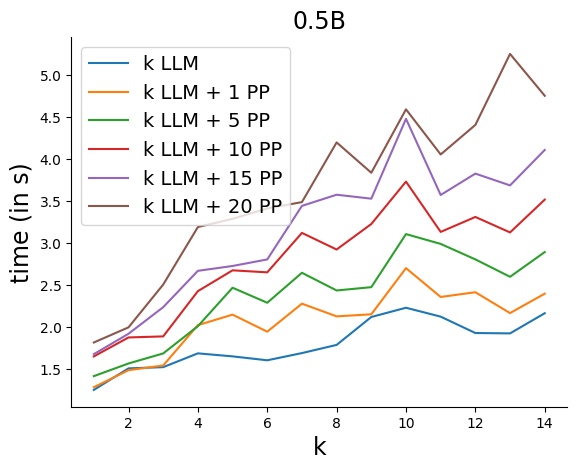

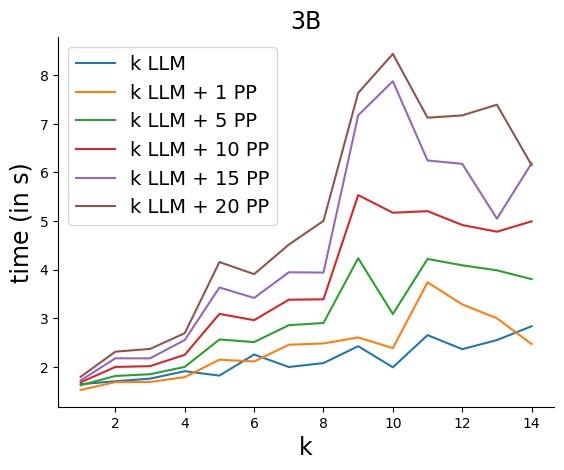

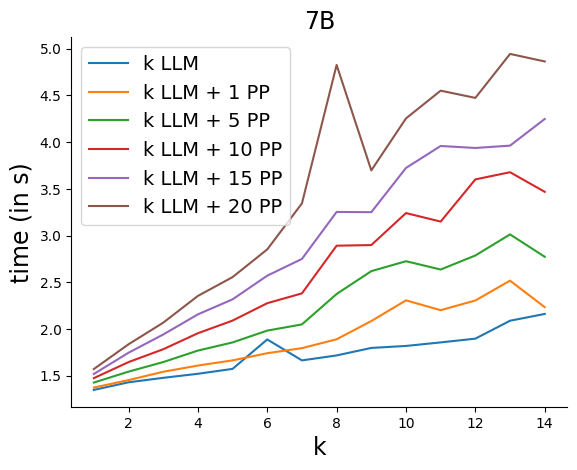

In [110]:
plotkvstime(0.5, "cruxeval_new")
plotkvstime(3, "cruxeval_new")
plotkvstime(7, "cruxeval_new")